In [12]:
import numpy as np
import matplotlib.pyplot as plt

## Module - 1

In [13]:
# Module 1 Coding Task : Interatomic Interactions
"""
Calculates reduced potential energy and force magnitude for a pair
of atoms .
TASK : Use the equations to implement the Lennard - Jones potential and
force .
REQUIREMENTS :
1. Implement the shifted potential : phi (r) - phi (rc).
2. Return the force magnitude divided by r ( force /r).
"""
def calculate_lj_properties(r_sq, r_cutoff_sq):
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)
    
    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2
    
    phi = 4 * (inv_r12 - inv_r6)
    

    potE = phi - phi_cut
    
    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)

    return potE, force_by_r


## Module - 2

In [14]:
def generate_fcc_lattice ( n_cells , rho_star ):

    """
    Generates an FCC lattice of atoms .
    TASK :
    1. Calculate the box length L based on density (rho = N/V).
    2. Place 4 atoms in each of the n_cells ^3 unit cells .
    """
    L = (4 * n_cells ** 3 / rho_star) ** (1 / 3)
    a = L / n_cells 
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (a)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)

    return np.array(positions), L


# YOUR CODE HERE
def apply_minimum_image (pos_i , pos_j , L):
    """
    Calculates the shortest distance vector between two atoms .
    TASK : Use the rounding logic to ensure dx ,
    dy , and dz
    are between -L/2 and L/2.
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr

## Module - 3

In [15]:
def calculate_total_force(pos, box_length, r_cutoff_sq):
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0

    for i in range(N - 1):
        for j in range(i + 1, N):
            dr = apply_minimum_image(pos[i], pos[j], box_length)
            r_sq = np.dot(dr, dr)
            if r_sq<r_cutoff_sq:
                pot, force_by_r = calculate_lj_properties(r_sq, r_cutoff_sq)
                f_vec = force_by_r * dr
                forces[i] -= f_vec
                forces[j] += f_vec
                total_pe += pot

    return total_pe, forces


# Module 3 Coding Task : The Integration Engine
def velocity_verlet_step(pos, vel, force, dt, box_length, r_cutoff_sq):
    """
    Advances the system by one time step dt using Velocity Verlet.
    TASK :
    1. Update positions .
    2. Apply Periodic Boundary Conditions ( wrap atoms back into box ).
    3. Update velocities (half - step ).
    4. Calculate new forces ( This will require your Module 1 & 2 logic ).
    5. Update velocities (full - step ).
    
    pos         : (N, 3) array — current position
    vel         : (N, 3) array — current velocity
    force       : (N, 3) array — current force
    dt          : float        — time step
    box_length  : float        — box length L
    r_cutoff_sq : float        — cutoff distance squared rc²

    pos_new   : (N, 3) — updated position
    vel_new   : (N, 3) — updated velocity
    pe_new    : float  — updated potential energy
    force_new : (N, 3) — updated force
    """
    # YOUR CODE HERE

    # Step 1: New Positions
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    # Step 2: PBC Wrap ( Module 2 logic )
    pos_new = pos_new % box_length
    # Step 3: Half - step velocity
    vel_mid = vel + 0.5 * force * dt
    # Step 4: New Forces ( Call your Module 1 force function here )
    pe_new, force_new = calculate_total_force(pos_new, box_length, r_cutoff_sq)
    # Step 5: Full - step velocity
    vel_new = vel_mid + 0.5 * force_new * dt

    return pos_new, vel_new, pe_new, force_new

**Module 3 Test — Energy Conservation & Relative Drift Check**

1. The velocity verlet is verified by checking energy conservation.
2. In a correctly implemented simulation, total energy E = KE + PE must remain constant, that is, no significant rise or fall over time.
4. We run 200 steps and measure: $\frac{RMS(E)}{|mean(E)|} < 10^{-4}$.
5. If this passes, the velocity verlet and force calculation are both correct.

In [25]:
# Calculate kinetic energy
def calculate_kinetic_energy(vel):
    """K* = 0.5 * sum(v²)   [m* = 1 in reduced units]"""
    return 0.5 * np.sum(vel**2)

# System setup
n_cells     = 3           # N = 4 * 3³ = 108 atoms
rho_star    = 0.8         # reduced density
dt          = 1e-3        # time step
r_cutoff_sq = 2.5**2      # standard LJ cutoff rc = 2.5 in reduced units

# Initialize positions on the FCC lattice
pos, L = generate_fcc_lattice(n_cells, rho_star)

# Initialize velocities at T* ≈ 1.0
# Draw each velocity component from a Gaussian with std = sqrt(T*)
# Subtract the mean so the whole block has zero net momentum
vel  = np.random.randn(*pos.shape) * np.sqrt(1.0)
vel -= vel.mean(axis=0)

# Calculate initial forces
pe, force = calculate_total_force(pos, L, r_cutoff_sq)

# Run 200 steps and save total energy
energies = []
for step in range(200):
    pos, vel, pe, force = velocity_verlet_step(pos, vel, force, dt, L, r_cutoff_sq)
    ke = calculate_kinetic_energy(vel)
    energies.append(ke + pe)       # E = KE + PE

# RMS energy fluctuation check
# RMS(E) = sqrt(mean((E - <E>)²))
# RMS(E) / |<E>| < 1e-4
E         = np.array(energies)
E_mean    = E.mean()
E_rms     = np.sqrt(np.mean((E - E_mean)**2))   # root mean square fluctuation
rel_drift = E_rms / abs(E_mean)

print(f"Mean E        : {E_mean:.4f}")
print(f"RMS  E        : {E_rms:.6f}")
print(f"Relative drift: {rel_drift:.2e}  (target < 1e-4)")
print("TEST PASSED" if rel_drift < 1e-4 else "TEST FAILED, reduce dt")

# Plot deviation from mean
# Flat line around zero implies energy conservation
# Any upward or downward trend implies drift
E_deviation = E - E_mean


Mean E        : -473.4605
RMS  E        : 0.001034
Relative drift: 2.18e-06  (target < 1e-4)
TEST PASSED


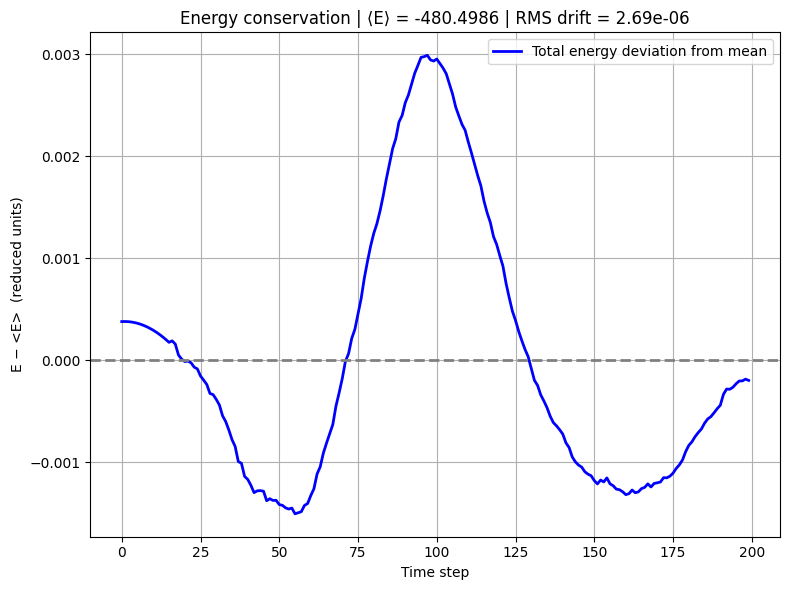

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(E)), E_deviation, color='blue', linewidth=2, label='Total energy deviation from mean')
plt.axhline(0, color='gray', linewidth=2, linestyle='--')
plt.xlabel('Time step')
plt.ylabel('E − <E>  (reduced units)')
plt.title(f'Energy conservation | 'f'⟨E⟩ = {E_mean:.4f} | 'f'RMS drift = {rel_drift:.2e}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Module 3 Test — Energy Conservation**

Generated 108 atoms in an FCC lattice with box length L = 5.1299
Initial Potential Energy: -639.8126


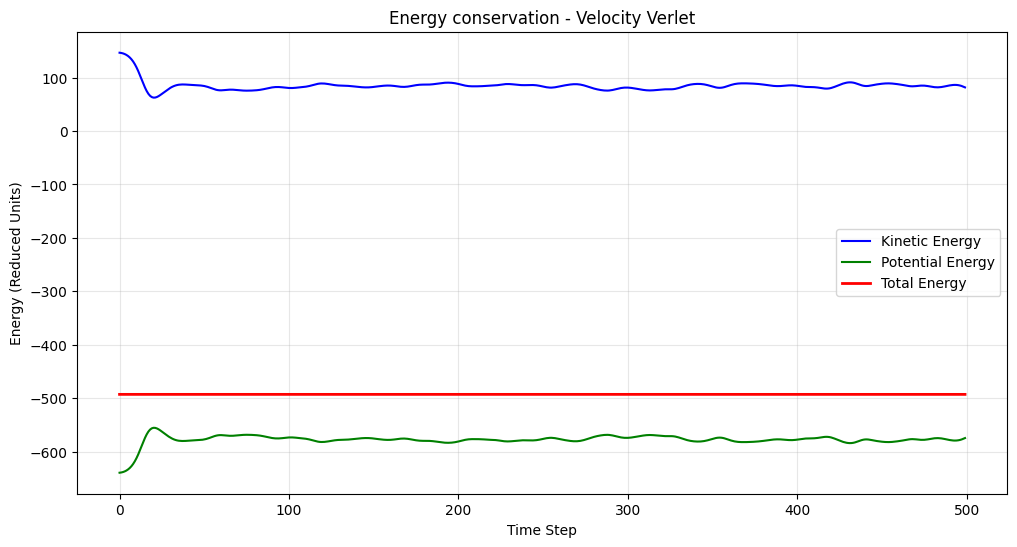

In [19]:
N_cell = 3
rho_star = 0.8
pos, L = generate_fcc_lattice(N_cell, rho_star)
print(f"Generated {len(pos)} atoms in an FCC lattice with box length L = {L:.4f}")
T_star = 1.0
vel = np.random.randn(*pos.shape) * np.sqrt(T_star)

delt_star = 5e-3
r_cutoff_star = 2.5
r_cutoff_sq = r_cutoff_star ** 2

pe, force = calculate_total_force(pos, L, r_cutoff_sq)
print(f"Initial Potential Energy: {pe:.4f}")
Nsteps = 500
Ke = []
Pe = []
energies = []
for step in range(Nsteps):
    pos, vel, pe, force = velocity_verlet_step(pos, vel, force, delt_star, L, r_cutoff_sq)
    ke = calculate_kinetic_energy(vel)
    Ke.append(ke)
    Pe.append(pe)
    energies.append(ke + pe)


plt.figure(figsize=(12, 6)) 
plt.plot(Ke, label='Kinetic Energy', color='blue')
plt.plot(Pe, label='Potential Energy', color='green')
plt.plot(energies, label='Total Energy', color='red', linewidth=2)
plt.title('Energy conservation - Velocity Verlet')
plt.xlabel('Time Step')
plt.ylabel('Energy (Reduced Units)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('m3_energy_conservation.pdf', dpi=300)
plt.show()

In [48]:
energies = np.array(energies)
E_mean = energies.mean()
E_rms = np.sqrt(np.mean((energies - E_mean) ** 2))
print(f"Mean Total Energy: {E_mean:.4f}")
print(f"RMS Fluctuation: {E_rms:.6f}")
print(f"Relative Energy Fluctuation: {E_rms / abs(E_mean):.4e}")

Mean Total Energy: -473.4605
RMS Fluctuation: 0.001034
Relative Energy Fluctuation: 2.1832e-06


**Module 3 Test — Time Step Check**

Generated 108 atoms in an FCC lattice with box length L = 5.1299
Initial Potential Energy for dt*=0.005: -639.8126
Initial Potential Energy for dt*=0.05: -639.8126


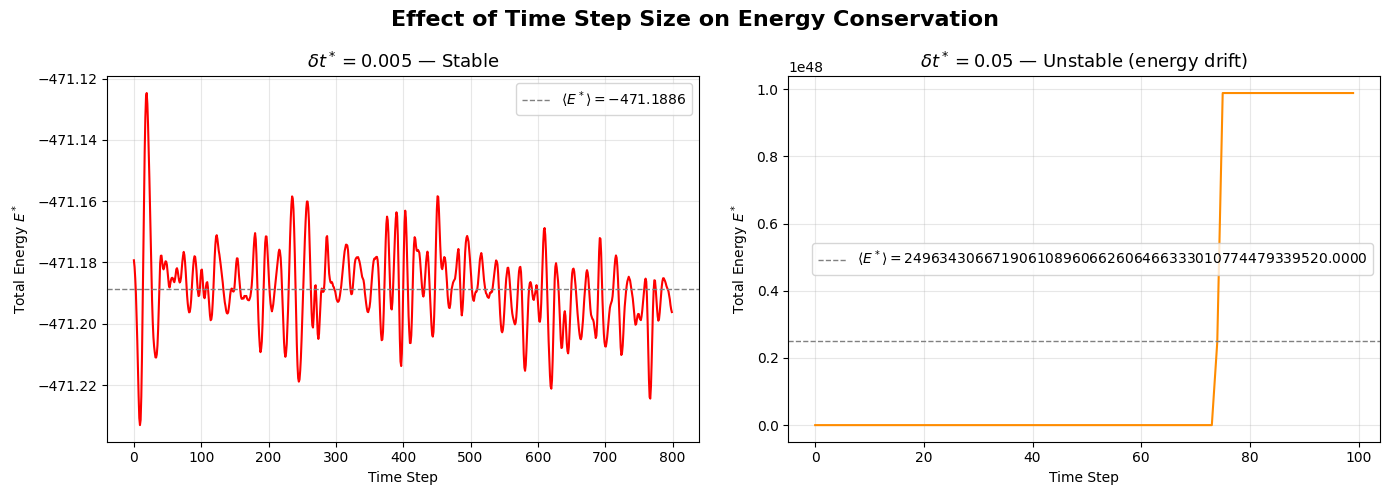

In [ ]:
# System setup
N_cell = 3
rho_star = 0.8
T_star = 1.0
r_cutoff_star = 2.5
r_cutoff_sq = r_cutoff_star ** 2

# Generate FCC lattice
pos, L = generate_fcc_lattice(N_cell, rho_star)
print(f"Generated {len(pos)} atoms in an FCC lattice with box length L = {L:.4f}")

# Initial velocities
vel = np.random.randn(*pos.shape) * np.sqrt(T_star)

# Time steps to compare
delta_t_values = [0.005, 0.05]

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of Time Step Size on Energy Conservation",
             fontsize=16, fontweight='bold')

for idx, delt_star in enumerate(delta_t_values):

    # Reset positions and velocities for fair comparison
    pos_temp = pos.copy()
    vel_temp = vel.copy()

    # Initial force + PE
    pe, force = calculate_total_force(pos_temp, L, r_cutoff_sq)
    print(f"Initial Potential Energy for dt*={delt_star}: {pe:.4f}")

    Nsteps = 800 if delt_star == 0.005 else 100
    energies = []

    # Time evolution
    for step in range(Nsteps):
        pos_temp, vel_temp, pe, force = velocity_verlet_step(
            pos_temp,
            vel_temp,
            force,
            delt_star,
            L,
            r_cutoff_sq
        )

        ke = calculate_kinetic_energy(vel_temp)
        total_energy = ke + pe
        energies.append(total_energy)

    energies = np.array(energies)
    avg_energy = np.mean(energies)

    ax = axes[idx]

    # Plot energy fluctuation around average
    ax.plot(
        energies,
        linewidth=1.5,
        color='red' if delt_star == 0.005 else 'darkorange'
    )

    # Dashed average energy line
    ax.axhline(
        avg_energy,
        linestyle='--',
        color='gray',
        linewidth=1,
        label=rf'$\langle E^* \rangle = {avg_energy:.4f}$'
    )

    # Title based on stability
    if delt_star == 0.005:
        title_text = rf'$\delta t^* = {delt_star}$ — Stable'
    else:
        title_text = rf'$\delta t^* = {delt_star}$ — Unstable (energy drift)'

    ax.set_title(title_text, fontsize=13)
    ax.set_xlabel("Time Step")
    ax.set_ylabel(r"Total Energy $E^*$")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('m3_timestep_comparison.pdf', dpi=300)
plt.show()